# Linear Regression on Network Traffic

In this hands-on assignment, we will explore learn models, in particular linear regression. Linear models can work well when there is a linear relationship between the target variable being predicted and the input features. In other words, when the target prediction can be modeled as a linear combination of the input features, linear models may be appropriate.

We'll explore the relationship beween bytes and packets in this hands-on, which may have a linear relationship at times. We will also explore how basis expansion---in particular polynomial basis expansion---can allow linear regression to fit more complex relationships between features and targets.

In [1]:
# Machine Learning Libraries
import numpy as np
import pandas as pd
from sklearn import linear_model

import logging
logging.getLogger("scapy.runtime").setLevel(logging.ERROR)

import sys
sys.path.insert(1,"/Users/feamster/research/netml/src/")
from netml.pparser.parser import PCAP
from netml.utils.tool import dump_data, load_data

# Plotting Library
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams["figure.figsize"] = (8,6)


## Part 1: Simple Linear Regression.

### Group Traffic Info Flows 

This example below uses a packet capture that is provided in the repository. You are also welcome (and encouraged!) to capture your own traffic.

Use `netml` to load the pcap and convert packets to flows, using pcap2flows.

In [2]:
hpcap = PCAP('data/http.pcap', flow_ptks_thres=2, verbose=10)
hpcap.pcap2flows()
len(hpcap.flows)

pcap_file: data/http.pcap
ith_packets: 0
ith_packets: 10000
ith_packets: 20000
len(flows): 593
total number of flows: 593. Num of flows < 2 pkts: 300, and >=2 pkts: 293 without timeout splitting.
kept flows: 293. Each of them has at least 2 pkts after timeout splitting.
flow_durations.shape: (293, 1)
        col_0
count 293.000
mean   11.629
std    15.820
min     0.000
25%     0.076
50%     0.455
75%    20.097
max    46.235
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 293 entries, 0 to 292
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   col_0   293 non-null    float64
dtypes: float64(1)
memory usage: 2.4 KB
None
0th_flow: len(pkts): 4
After splitting flows, the number of subflows: 291 and each of them has at least 2 packets.


291

### Generate Features

Use the `netml` "STATS" option to generate features for each flow, which will provide the following features for each flow:

0. Duration
1. Packets per second
2. Bytes per second
3. Mean packet size
4. Standard deviation of packet sizes
5. 25th, median, 75th, min, max packet sizes

The exercise below requires a [slight modification](https://github.com/chicago-cdac/netml/pull/16/commits/79c0f930f2882c7bf042a9eb45e2a6ac413a695d) to the `netml` library (for versions <= 0.2.1) to add two additional features:
* number of packets per flow
* number of bytes per flow

You can modify the library (line 455 of `parser.py`) to add total number of packets and bytes per flow, or optionally explore the relationships between some of the other features.

In [4]:
hpcap.flow2features('STATS', fft = False, header = False)
features = pd.DataFrame(hpcap.features)
features.head()
features.columns
features.shape
features.describe()
features.describe()


True


,0,1,2,3,4,5,6,7,8,9,10,11
count,291.000,291.000,291.000,291.000,291.000,291.000,291.000,291.000,291.000,291.000,291.000,291.000
mean,11.075,1229.589,237653.463,345.198,241.741,204.022,284.392,454.225,67.443,770.784,84.165,100124.914
std,15.368,7075.216,1097806.844,387.674,220.520,402.558,459.163,549.922,10.371,562.601,355.977,517703.464
min,0.000,0.105,7.944,60.000,0.000,60.000,60.000,60.000,60.000,60.000,2.000,120.000
25%,0.069,0.692,99.181,96.648,28.382,66.000,66.000,98.500,66.000,123.000,6.000,945.000
50%,0.388,47.436,8360.315,152.143,166.543,66.000,81.000,123.000,66.000,583.000,11.000,2053.000
75%,18.541,150.296,36871.363,432.292,417.087,74.000,123.000,674.250,66.000,1466.000,16.500,6134.000
max,45.073,66576.254,11525234.160,1495.744,720.672,1514.000,1514.000,1514.000,156.000,1514.000,2985.000,4464796.000


In [6]:
X = features[[10]].values # packets per flow 
y = features[[11]].values # bytes per flow

duration = features[0]
packets = duration * features[1] #duration * packets / sec 
bytes = duration * features[2] #duration * bytes / sec 

duration 
packets 
bytes

0         350.000
1         344.000
2         330.000
3         330.000
4         158.000
5        2873.000
6         162.000
7        6605.000
8         823.000
9        1049.000
10       3596.000
11       2375.000
12       4765.000
13       3006.000
14       2783.000
15       6449.000
16       1181.000
17       1181.000
18       1181.000
19       1011.000
20       1011.000
21       1011.000
22        493.000
23        259.000
24       1247.000
25       2053.000
26       2207.000
27       3290.000
28        614.000
29        630.000
30        820.000
31        470.000
32       2108.000
33       1247.000
34       1181.000
35       1181.000
36       1247.000
37       1181.000
38       2058.000
39        945.000
40       1011.000
41       1011.000
42       2058.000
43       1247.000
44       1001.000
45       1724.000
46        473.000
47       1247.000
48        324.000
49       2055.000
50       4622.000
51       3803.000
52        148.000
53        192.000
54        126.000
55        

### Train Model

Explore the relationship between some of these features. A natural one to explore is the relationship between the number of bytes in a flow and the number of packets in a flow.

Train a `Linear Regression` model from scikit learn to model this relationship, and output the resulting predictions into a vector `y_hat`.

In [7]:
from sklearn.linear_model import LinearRegression 

model = LinearRegression() 
model.fit(X, y) 
y_hat = model.predict(X) 

print("Coefficients (slope):", model.coef_[0])
print("Intercept:", model.intercept_)

Coefficients (slope): [1447.22084158]
Intercept: [-21680.35344346]


### Visualize Your Model

Plot the relationship that your model has learned, by plotting the learned model (which should be a line), along with the points.  Label your axes!

What do you notice about the relationship, and how it relates to the original points?

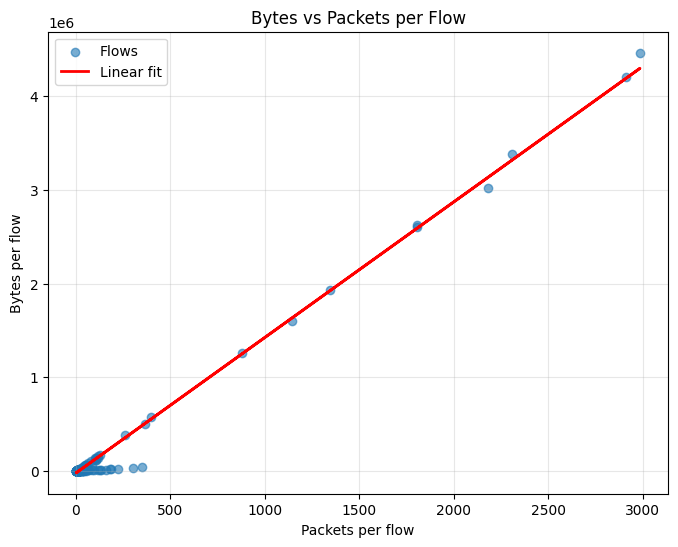

In [9]:
plt.scatter(X, y, alpha = 0.6, label="Flows")
plt.plot(X, y_hat, color="red", linewidth=2, label="Linear fit")
plt.xlabel("Packets per flow")
plt.ylabel("Bytes per flow")
plt.title("Bytes vs Packets per Flow")
plt.legend() 
plt.grid(True, alpha = 0.3)
plt.show()

### Evaluation: Error Computation

You can compute how well your manual fit is by computing the error, in terms of residual sum of squares.

In [10]:
rss = np.sum((y_hat - y) ** 2)
print("Resideual Sum of Squares(RSS):", rss)

Resideual Sum of Squares(RSS): 756516822104.062


In [11]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y, y_hat)
rmse = np.sqrt(mse)
r2 = r2_score(y, y_hat)

print("MSE:", mse)
print("RMSE (bytes):", rmse)
print("R²:", r2)

MSE: 2599714165.306055
RMSE (bytes): 50987.392219116824
R²: 0.9902667371785954


## Part 2: Polynomial Basis Expansion

Recall that one of the benefits of a polynomial feature expansion is that it is possible to fit a linear model to a resulting polynomial expansion of the features.

We will do that below.  Let's first create the regular features and then the polynomial expansion. You will need the `PolynomialFeatures` library from `sklearn.preprocessing`, as well as the `fit_transform` function to generate your feature expansion.

Train the linear regression model on the expanded set of features, and generate a new set of predictions, `y_hat_poly`.

In [14]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)
X_poly[:5]

model_poly = LinearRegression() 
model_poly.fit(X_poly, y) 
y_hat_poly = model_poly.predict(X_poly) 

print("Polynomial coefficients:", model_poly.coef_)
print("Intercept:", model_poly.intercept_)

Polynomial coefficients: [[1.24552466e+03 8.49957477e-02]]
Intercept: [-16040.33017368]


Visualize your results again. What do you notice about the predicted values?

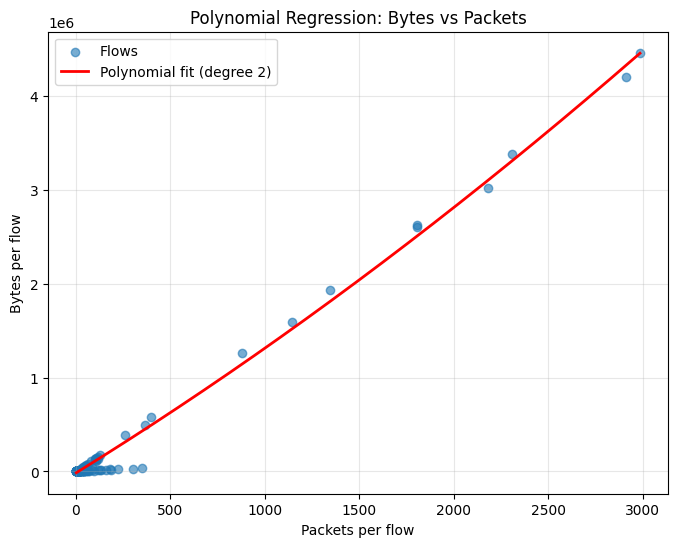

In [21]:
X_plot = np.linspace(X.min(), X.max(), 200).reshape(-1, 1) 
X_plot_poly = poly.transform(X_plot)
y_plot_poly = model_poly.predict(X_plot_poly)

plt.scatter(X, y, alpha=0.6, label= "Flows")
plt.plot(X_plot, y_plot_poly, color="red", linewidth=2, label="Polynomial fit (degree 2)")
plt.xlabel("Packets per flow")
plt.ylabel("Bytes per flow") 
plt.title("Polynomial Regression: Bytes vs Packets") 

plt.legend() 
plt.grid(True, alpha = 0.3) 
plt.show() 

Evaluate your error once again. What happened to overall mean squared error?

In [24]:
rss_poly = np.sum((y - y_hat_poly) ** 2)
print("Resideual Sum of Squares(RSS):", rss_poly)

Resideual Sum of Squares(RSS): 635851266933.1995


In [26]:
from sklearn.metrics import mean_squared_error, r2_score

mse_poly = mean_squared_error(y, y_hat_poly)
rmse_poly = np.sqrt(mse_poly)
r2_poly = r2_score(y, y_hat_poly)

print("MSE:", mse_poly)
print("RMSE (bytes):", rmse_poly)
print("R²:", r2_poly)

MSE: 2185055900.1140876
RMSE (bytes): 46744.581505390415
R²: 0.9918192070347213


## Part 3: Exploring Relationships between Other Features

In the earlier parts of this hands-on, we explored simple relationship between features and outcome variables. You can extend your analysis by exploring other relationships, such as the relationships between one or more of the features already output from `netml`.

## Bonus: Reducing Error on Test Set

In the above example, we used a polynomial basis expansion to reduce the error on the training set. But, we have no test set, so it is difficult to tell whether the model above is overfit to the training data.

In order for us to tell whether this model is a good fit, we need to test it on data that the model has not yet seen. This requires splitting the data into a training set and a test set.

A typical split between training data and test data might be 80% training data, 20% test data. You can also perform this process repeatedly and average the results. This process is called **cross-validation**.

### Part 1

1. Take a packet trace using wireshark and load it into the notebook.
2. Perform a simple linear regression fit and a fit with basis expansion (same as above), comparing errors.

The first two steps are the same as above, but you might try doing this for a larger sample so that your network traffic has more flows (i.e., data points).

### Part 2

3. Use functions from sklearn to split the data into training and testing. (train_test_split, or sklearn's CV function).
4. How does model accuracy compare for different polynomial basis expansions? (n=1, 2, 3, ?) At what point is the model overfit?
5. Can you experiment with a regularization parameter to control or reduce overfitting?